In [1]:
''' ENERGY CONSUMPTION PREDICTOR-> Predicts eenergy consuption using 
the best model trainedin Phase 2.
'''

' ENERGY CONSUMPTION PREDICTOR-> Predicts eenergy consuption using \nthe best model trainedin Phase 2.\n'

In [2]:
import joblib
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

In [3]:
# STEP 1 - load all saved model files
print("ENERGY CONSUMPTION PREDICTOR\n")
# check if saved_model folder exists
if not os.path.exists("saved_model"):
    print("ERROR: 'saved_model' folder not found!")
    print("Please run export_model.py in your notebook first.")
    exit()

# load the trained model
model = joblib.load("saved_model/best_model.pkl")

# load the scaler
scaler = joblib.load("saved_model/scaler.pkl")

# load the label encoders
label_encoders = joblib.load("saved_model/label_encoders.pkl")

# load model_info dictionary (contains medians, feature names, metadata)
model_info = joblib.load("saved_model/model_info.pkl")

# unpack the values we need from the dictionary
medians             = model_info["medians"]
feature_names       = model_info["feature_names"]
numerical_columns   = model_info["numerical_columns"]
categorical_columns = model_info["categorical_columns"]

print(f"Model loaded     : {model_info['model_name']}")
print(f"R2 Score         : {model_info['best_r2_score']}")
print(f"RMSE             : {model_info['best_rmse']} kWh")
print()

# load prediction history from CSV file-> We use a simple CSV file to remember all past predictions
HISTORY_FILE = "prediction_history.csv"

if os.path.exists(HISTORY_FILE):
    # load existing history from CSV
    history_df = pd.read_csv(HISTORY_FILE)
else:
    # create a new empty dataframe with the columns we want to track
    history_df = pd.DataFrame(columns=[
        "prediction_no", "predicted_kWh", "level",
        "season", "building", "shift", "students", "temperature"
    ])

ENERGY CONSUMPTION PREDICTOR

Model loaded     : GradientBoostingRegressor
R2 Score         : 0.8146
RMSE             : 30.46 kWh



In [4]:
# STEP 2 - Helper functions
def get_number_input(prompt, min_val=None, max_val=None, default=None):
    """
    Ask the user for a number.
    If they enter nothing or something invalid, use the default (median) value.
    """
    while True:
        raw = input(prompt).strip()

        if raw == "" and default is not None:
            print(f"   (using default: {round(default, 2)})")
            return default

        try:
            value = float(raw)

            if min_val is not None and value < min_val:
                print(f"   Value too low. Minimum is {min_val}. Try again.")
                continue
            if max_val is not None and value > max_val:
                print(f"   Value too high. Maximum is {max_val}. Try again.")
                continue

            return value

        except ValueError:
            if default is not None:
                print(f"   Invalid input. Using default: {round(default, 2)}")
                return default
            else:
                print("   Please enter a valid number.")


def get_category_input(prompt, valid_options, encoder):
    """
    Ask the user to choose from a list of categories.
    Returns both the encoded integer AND the original string label.
    """
    options_str = " / ".join(valid_options)
    full_prompt  = f"{prompt}\n   Options: {options_str}\n   Your choice: "

    while True:
        raw = input(full_prompt).strip()

        if raw == "":
            default_choice = valid_options[0]
            print(f"   (using default: {default_choice})")
            return int(encoder.transform([default_choice])[0]), default_choice

        if raw in valid_options:
            return int(encoder.transform([raw])[0]), raw

        raw_lower = raw.lower()
        for option in valid_options:
            if option.lower() == raw_lower:
                print(f"   Matched to: {option}")
                return int(encoder.transform([option])[0]), option

        print(f"   '{raw}' is not a valid option. Please choose from: {options_str}")

In [5]:
# STEP 3 - collect input from user
print("Please enter the following details.\n")
print("Press ENTER to use the default value shown in brackets.\n")


user_input  = {}   # stores encoded values for the model
input_labels = {}  # stores original string values for display in graphs

# NUMERICAL INPUTS 

print("\t\t\tNUMERICAL INPUTS\n")


user_input['Time_of_Day'] = get_number_input(
    f"Time of Day (0-23, default={round(medians['Time_of_Day'])}): ",
    min_val=0, max_val=23, default=medians['Time_of_Day']
)
user_input['Students_Present'] = get_number_input(
    f"Students Present (0-1000, default={round(medians['Students_Present'])}): ",
    min_val=0, max_val=1000, default=medians['Students_Present']
)
user_input['Temperature_C'] = get_number_input(
    f"Temperature in Celsius (default={round(medians['Temperature_C'], 1)}): ",
    min_val=-10, max_val=55, default=medians['Temperature_C']
)
user_input['Appliance_Usage'] = get_number_input(
    f"Appliance Usage (0-100, default={round(medians['Appliance_Usage'], 1)}): ",
    min_val=0, max_val=100, default=medians['Appliance_Usage'])

user_input['Day_of_Week'] = get_number_input(
    f"Day of Week (0=Mon to 6=Sun, default={round(medians['Day_of_Week'])}): ",
    min_val=0, max_val=6, default=medians['Day_of_Week'])

user_input['Month'] = get_number_input(
    f"Month (1-12, default={round(medians['Month'])}): ",
    min_val=1, max_val=12, default=medians['Month'])

user_input['Humidity_Percent'] = get_number_input(
    f"Humidity Percent (0-100, default={round(medians['Humidity_Percent'], 1)}): ",
    min_val=0, max_val=100, default=medians['Humidity_Percent'])

user_input['Wind_Speed_kmh'] = get_number_input(
    f"Wind Speed km/h (default={round(medians['Wind_Speed_kmh'], 1)}): ",
    min_val=0, default=medians['Wind_Speed_kmh'])

user_input['Solar_Radiation_Wm2'] = get_number_input(
    f"Solar Radiation W/m2 (default={round(medians['Solar_Radiation_Wm2'], 1)}): ",
    min_val=0, default=medians['Solar_Radiation_Wm2'])

user_input['HVAC_Usage_kW'] = get_number_input(
    f"HVAC Usage kW (default={round(medians['HVAC_Usage_kW'], 1)}): ",
    min_val=0, default=medians['HVAC_Usage_kW'])

user_input['Lighting_Usage_kW'] = get_number_input(
    f"Lighting Usage kW (default={round(medians['Lighting_Usage_kW'], 1)}): ",
    min_val=0, default=medians['Lighting_Usage_kW'])

user_input['Water_Usage_Liters'] = get_number_input(
    f"Water Usage Liters (default={round(medians['Water_Usage_Liters'], 1)}): ",
    min_val=0, default=medians['Water_Usage_Liters'])

user_input['CO2_Level_ppm'] = get_number_input(
    f"CO2 Level ppm (default={round(medians['CO2_Level_ppm'], 1)}): ",
    min_val=0, default=medians['CO2_Level_ppm'])


# CATEGORICAL INPUTS 
print("\t\t\t CATEGORICAL INPUTS \n")

user_input['Season'],input_labels['Season']= get_category_input("Season",list(label_encoders['Season'].classes_), 
                                                                label_encoders['Season'])
user_input['Building_Type'],input_labels['Building_Type']= get_category_input("Building Type",list(label_encoders['Building_Type'].classes_),
                                                                               label_encoders['Building_Type'])
user_input['Weather_Condition'],input_labels['Weather_Condition']= get_category_input("Weather Condition",
                                                                                      list(label_encoders['Weather_Condition'].classes_),
                                                                                      label_encoders['Weather_Condition'])
user_input['Occupancy_Level'],input_labels['Occupancy_Level']= get_category_input("Occupancy Level",list(label_encoders['Occupancy_Level'].classes_),
                                                                                  label_encoders['Occupancy_Level'])
user_input['Shift'],input_labels['Shift']= get_category_input("Shift",list(label_encoders['Shift'].classes_),
                                                              label_encoders['Shift'])
user_input['HVAC_Mode'],input_labels['HVAC_Mode']= get_category_input("HVAC Mode",list(label_encoders['HVAC_Mode'].classes_),
                                                                      label_encoders['HVAC_Mode'])
user_input['Event_Type'],input_labels['Event_Type']= get_category_input("Event Type",list(label_encoders['Event_Type'].classes_),
                                                                        label_encoders['Event_Type'])
user_input['Maintenance_Status'],input_labels['Maintenance_Status'] = get_category_input("Maintenance Status",
                                                                                         list(label_encoders['Maintenance_Status'].classes_),
                                                                                         label_encoders['Maintenance_Status'])

Please enter the following details.

Press ENTER to use the default value shown in brackets.

			NUMERICAL INPUTS



Time of Day (0-23, default=12):  


   (using default: 12.0)


Students Present (0-1000, default=282):  


   (using default: 281.5)


...

   (using default: Auto)


Event Type
   Options: EXAM / Exam / Holiday / No_Event / Regular_Class / Seminar / Sports_Event / Workshop
   Your choice:  


   (using default: EXAM)


Maintenance Status
   Options: Normal / Post_Maintenance / Scheduled_Check / Under_Maintenance / nan
   Your choice:  


   (using default: Normal)


In [6]:
# STEP 4 - build dataframe from input
input_df = pd.DataFrame([user_input])
print("Input received:")
for col, val in user_input.items():
    print(f"  {col:25s}: {val}")

Input received:
  Time_of_Day              : 12.0
  Students_Present         : 281.5
  Temperature_C            : 27.91
  Appliance_Usage          : 30.0
  Day_of_Week              : 4.0
  Month                    : 7.0
  Humidity_Percent         : 62.5
  Wind_Speed_kmh           : 25.25
  Solar_Radiation_Wm2      : 172.3
  HVAC_Usage_kW            : 15.024999999999999
  Lighting_Usage_kW        : 7.755
  Water_Usage_Liters       : 1514.45
  CO2_Level_ppm            : 540.5
  Season                   : 0
  Building_Type            : 0
  Weather_Condition        : 0
  Occupancy_Level          : 0
  Shift                    : 0
  HVAC_Mode                : 0
  Event_Type               : 0
  Maintenance_Status       : 0


In [13]:
# STEP 5 - create interaction features (same as training)
input_df['CO2_x_Students']       = input_df['CO2_Level_ppm']    * input_df['Students_Present']
input_df['Temp_x_Humidity']      = input_df['Temperature_C']    * input_df['Humidity_Percent']
input_df['HVAC_x_Appliance']     = input_df['HVAC_Usage_kW']    * input_df['Appliance_Usage']
input_df['Students_x_Appliance'] = input_df['Students_Present'] * input_df['Appliance_Usage']

# STEP 6 - reorder columns to match training order
input_df = input_df[feature_names]

# STEP 7 - scale using saved scaler
input_scaled = scaler.transform(input_df)

# STEP 8 - make the prediction
prediction = model.predict(input_scaled)[0]
prediction = max(0, prediction)   # energy cannot be negative

In [14]:
# STEP 9 - display the result
print("\t\t\tPREDICTION RESULT\n")
print(f"  Predicted Energy Consumption : {prediction:.2f} kWh")
print()

if prediction < 50:
    level       = "Very Low"
    level_color = "#2196F3"
    note        = "Minimal activity - likely off-hours or holiday"
elif prediction < 150:
    level       = "Low"
    level_color = "#4CAF50"
    note        = "Light usage - few appliances or students present"
elif prediction < 250:
    level       = "Moderate"
    level_color = "#FF9800"
    note        = "Normal day with regular activity"
elif prediction < 350:
    level       = "High"
    level_color = "#F44336"
    note        = "Heavy usage - many students, high appliance load"
else:
    level       = "Very High"
    level_color = "#9C27B0"
    note        = "Peak usage - consider energy saving measures"

print(f"  Consumption Level  : {level}")
print(f"  Interpretation     : {note}")
print()
print(f"  Model Used         : {model_info['model_name']}")
print(f"  Model R2 Score     : {model_info['best_r2_score']}")
print(f"  Model RMSE         : {model_info['best_rmse']} kWh")
print()
rmse = model_info['best_rmse']
print(f"  Likely range       : {max(0, prediction - rmse):.2f} kWh  to  {prediction + rmse:.2f} kWh")

			PREDICTION RESULT

  Predicted Energy Consumption : 264.70 kWh

  Consumption Level  : High
  Interpretation     : Heavy usage - many students, high appliance load

  Model Used         : GradientBoostingRegressor
  Model R2 Score     : 0.8146
  Model RMSE         : 30.46 kWh

  Likely range       : 234.24 kWh  to  295.16 kWh


In [15]:
''' Plot 4 graphs after each prediction
Graph 1 : Energy Gauge- shows where prediction falls on a scale
Graph 2 : Input vs Median- compares user input to typical values
Graph 3 : Feature Importance- which features matter most
Graph 4 : Prediction History- all predictions made so far
'''

' Plot 4 graphs after each prediction\nGraph 1 : Energy Gauge- shows where prediction falls on a scale\nGraph 2 : Input vs Median- compares user input to typical values\nGraph 3 : Feature Importance- which features matter most\nGraph 4 : Prediction History- all predictions made so far\n'

In [20]:
#Save this prediction to history CSV
prediction_number = len(history_df) + 1

# create a new row as a small one-row dataframe then add it to history
new_row = pd.DataFrame([{
    "prediction_no" : prediction_number,
    "predicted_kWh" : round(float(prediction), 2),
    "level"         : level,
    "season"        : input_labels.get('Season', ''),
    "building"      : input_labels.get('Building_Type', ''),
    "shift"         : input_labels.get('Shift', ''),
    "students"      : user_input.get('Students_Present', 0),
    "temperature"   : user_input.get('Temperature_C', 0),
}])

# pd.concat joins the new row to the existing history dataframe
history_df = pd.concat([history_df, new_row], ignore_index=True)

# save updated history back to CSV file
history_df.to_csv(HISTORY_FILE, index=False)

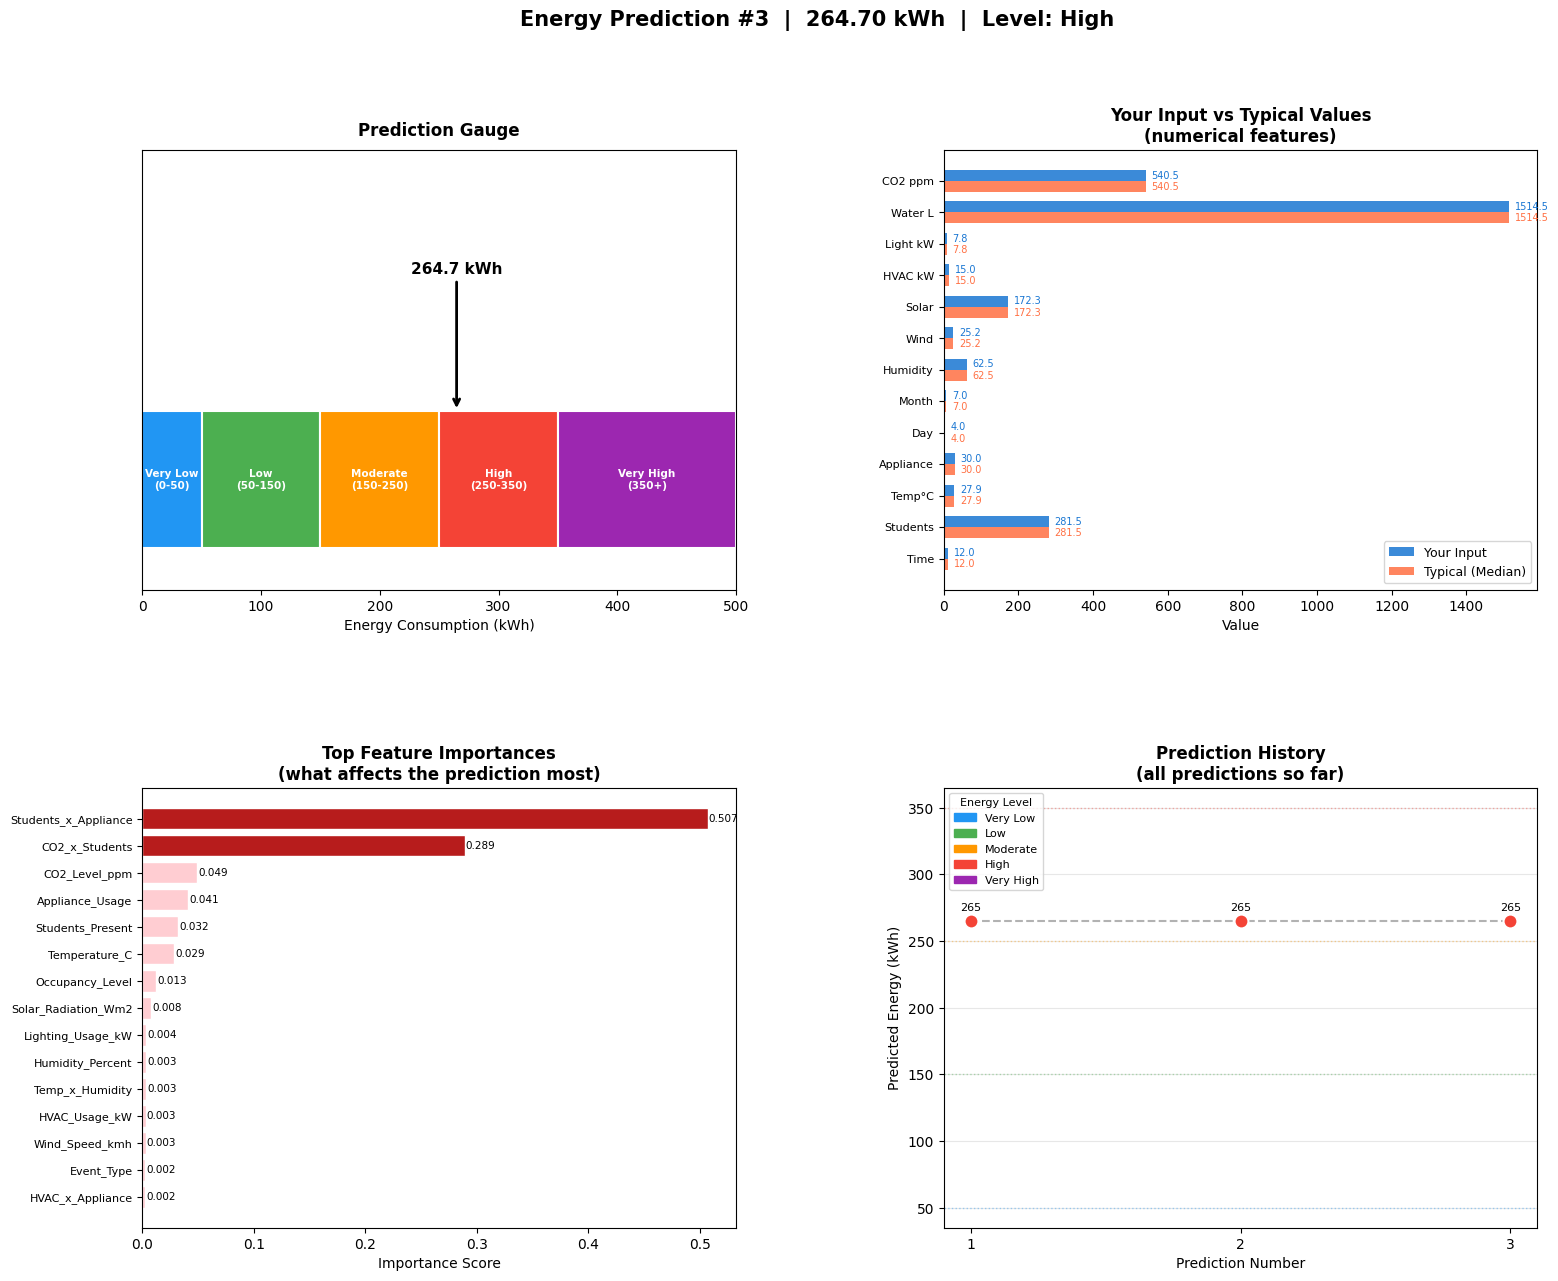

In [21]:
# create the 4-panel figure
fig = plt.figure(figsize=(18, 14))
fig.suptitle(f"Energy Prediction #{prediction_number}  |  {prediction:.2f} kWh  |  Level: {level}",fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])   
ax2 = fig.add_subplot(gs[0, 1])   
ax3 = fig.add_subplot(gs[1, 0])   
ax4 = fig.add_subplot(gs[1, 1]) 



# GRAPH 1: ENERGY GAUGE 
zone_limits = [0, 50, 150, 250, 350, 500]
zone_labels = ['Very Low\n(0-50)', 'Low\n(50-150)', 'Moderate\n(150-250)',
               'High\n(250-350)', 'Very High\n(350+)']
zone_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

for i in range(len(zone_colors)):
    ax1.barh(0, zone_limits[i+1] - zone_limits[i], left=zone_limits[i],
             height=0.5, color=zone_colors[i], edgecolor='white', linewidth=1.5)
    mid = (zone_limits[i] + zone_limits[i+1]) / 2
    ax1.text(mid, 0, zone_labels[i], ha='center', va='center',
             fontsize=7.5, color='white', fontweight='bold')

display_pred = min(prediction, 499)
ax1.annotate(
    f"{prediction:.1f} kWh",
    xy=(display_pred, 0.25), xytext=(display_pred, 0.75),
    fontsize=11, fontweight='bold', color='black', ha='center',
    arrowprops=dict(arrowstyle='->', color='black', lw=2)
)
ax1.set_xlim(0, 500)
ax1.set_ylim(-0.4, 1.2)
ax1.set_yticks([])
ax1.set_xlabel("Energy Consumption (kWh)", fontsize=10)
ax1.set_title("Prediction Gauge", fontsize=12, fontweight='bold', pad=10)



# GRAPH 2: USER INPUT vs MEDIAN
user_vals   = [user_input[col] for col in numerical_columns]
median_vals = [medians[col]    for col in numerical_columns]
short_labels = ['Time', 'Students', 'Temp°C', 'Appliance', 'Day', 'Month',
                'Humidity', 'Wind', 'Solar', 'HVAC kW', 'Light kW', 'Water L', 'CO2 ppm']

y_pos  = np.arange(len(numerical_columns))
height = 0.35

bars_user   = ax2.barh(y_pos + height/2, user_vals,   height, label='Your Input',        color='#1976D2', alpha=0.85)
bars_median = ax2.barh(y_pos - height/2, median_vals, height, label='Typical (Median)',  color='#FF7043', alpha=0.85)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(short_labels, fontsize=8)
ax2.set_xlabel("Value", fontsize=10)
ax2.set_title("Your Input vs Typical Values\n(numerical features)", fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')

max_user   = max(user_vals)   if max(user_vals)   > 0 else 1
max_median = max(median_vals) if max(median_vals) > 0 else 1
for bar in bars_user:
    w = bar.get_width()
    ax2.text(w + max_user * 0.01, bar.get_y() + bar.get_height()/2,
             f'{w:.1f}', va='center', fontsize=7, color='#1976D2')
for bar in bars_median:
    w = bar.get_width()
    ax2.text(w + max_median * 0.01, bar.get_y() + bar.get_height()/2,
             f'{w:.1f}', va='center', fontsize=7, color='#FF7043')


# GRAPH 3: FEATURE IMPORTANCE
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    imp_df = pd.DataFrame({
        'Feature'    : feature_names,
        'Importance' : importances
    }).sort_values('Importance', ascending=True).tail(15)

    bar_colors = ['#B71C1C' if v > 0.1 else '#EF9A9A' if v > 0.05 else '#FFCDD2'
                  for v in imp_df['Importance']]

    ax3.barh(imp_df['Feature'], imp_df['Importance'], color=bar_colors, edgecolor='white')
    ax3.set_xlabel("Importance Score", fontsize=10)
    ax3.set_title("Top Feature Importances\n(what affects the prediction most)", fontsize=12, fontweight='bold')
    for i, (val, name) in enumerate(zip(imp_df['Importance'], imp_df['Feature'])):
        ax3.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=7.5)
    ax3.set_yticklabels(imp_df['Feature'], fontsize=8)
else:
    ax3.text(0.5, 0.5, 'Feature importance\nnot available\nfor this model type',
             ha='center', va='center', fontsize=12, transform=ax3.transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax3.set_title("Feature Importance", fontsize=12, fontweight='bold')




# GRAPH 4: PREDICTION HISTORY 
history_nums   = history_df["prediction_no"].tolist()
history_vals   = history_df["predicted_kWh"].tolist()
history_levels = history_df["level"].tolist()

level_color_map = {
    'Very Low' : '#2196F3',
    'Low'      : '#4CAF50',
    'Moderate' : '#FF9800',
    'High'     : '#F44336',
    'Very High': '#9C27B0'
}
dot_colors = [level_color_map.get(lv, 'gray') for lv in history_levels]

ax4.plot(history_nums, history_vals, color='gray', linewidth=1.5, linestyle='--', zorder=1, alpha=0.6)

for x, y, c in zip(history_nums, history_vals, dot_colors):
    ax4.scatter(x, y, color=c, s=100, zorder=2, edgecolors='white', linewidths=1.5)

for x, y in zip(history_nums, history_vals):
    ax4.annotate(f'{y:.0f}', (x, y), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=8)

ax4.axhline(y=50,  color='#2196F3', linestyle=':', alpha=0.4, linewidth=1)
ax4.axhline(y=150, color='#4CAF50', linestyle=':', alpha=0.4, linewidth=1)
ax4.axhline(y=250, color='#FF9800', linestyle=':', alpha=0.4, linewidth=1)
ax4.axhline(y=350, color='#F44336', linestyle=':', alpha=0.4, linewidth=1)

ax4.set_xlabel("Prediction Number", fontsize=10)
ax4.set_ylabel("Predicted Energy (kWh)", fontsize=10)
ax4.set_title("Prediction History\n(all predictions so far)", fontsize=12, fontweight='bold')
ax4.set_xticks(history_nums)
ax4.grid(axis='y', alpha=0.3)

legend_patches = [mpatches.Patch(color=c, label=lv) for lv, c in level_color_map.items()]
ax4.legend(handles=legend_patches, fontsize=8, loc='upper left',
           title='Energy Level', title_fontsize=8)
plt.show()

In [24]:
print()
again = input("Do you want to make another prediction? (yes/no): ").strip().lower()
if again in ['yes', 'y']:
    print()
    exec(open(__file__).read())
else:
    print()
    print("Thank you for using the Energy Consumption Predictor!")
    print(f"Total predictions made: {len(history_df)}")
    print(f"History CSV saved as  : {HISTORY_FILE}")

Do you want to make another prediction? (yes/no):  no



Thank you for using the Energy Consumption Predictor!
Total predictions made: 3
History CSV saved as  : prediction_history.csv
